<a href="https://colab.research.google.com/github/weronix123/customer-churn/blob/dev/churn_projekt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Importowanie bibliotek i wczytanie danych**

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import pickle
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, auc, accuracy_score,
    precision_score, recall_score, f1_score
)
from sklearn.compose import ColumnTransformer
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/customer_churn_dataset-training-master.csv')
df_test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/customer_churn_dataset-testing-master.csv')


In [35]:
df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


## **Eksploracja wstępna**

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [37]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [38]:
df.shape

(440833, 12)

In [39]:
df.dtypes

,0
CustomerID,float64
Age,float64
Gender,object
Tenure,float64
Usage Frequency,float64
Support Calls,float64
Payment Delay,float64
Subscription Type,object
Contract Length,object
Total Spend,float64


## **Czyszczenie danych**

In [40]:
df.isnull().sum()

,0
CustomerID,1
Age,1
Gender,1
Tenure,1
Usage Frequency,1
Support Calls,1
Payment Delay,1
Subscription Type,1
Contract Length,1
Total Spend,1


In [41]:
df = df.dropna()
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0


In [42]:
df = df.drop(columns=["CustomerID"])
df.columns

Index(['Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls',
       'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend',
       'Last Interaction', 'Churn'],
      dtype='object')

In [43]:
print('Duplikaty przed:', df.duplicated().sum())
df = df.drop_duplicates()
print('Duplikaty po:', df.duplicated().sum())

Duplikaty przed: 0
Duplikaty po: 0


In [44]:
df.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


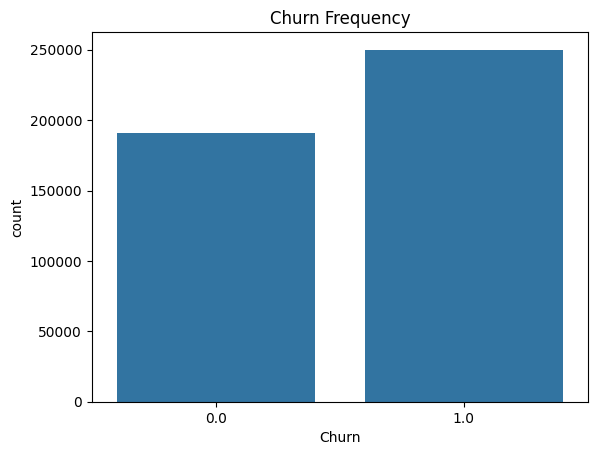

In [45]:
df['Churn'].value_counts(normalize=True)
sns.countplot(x='Churn', data=df)
plt.title('Churn Frequency')
plt.show()

In [46]:
df['Churn'] = df['Churn'].astype(int)
df_test['Churn'] = df_test['Churn'].astype(int)

## **Rozkład wartości odstających**

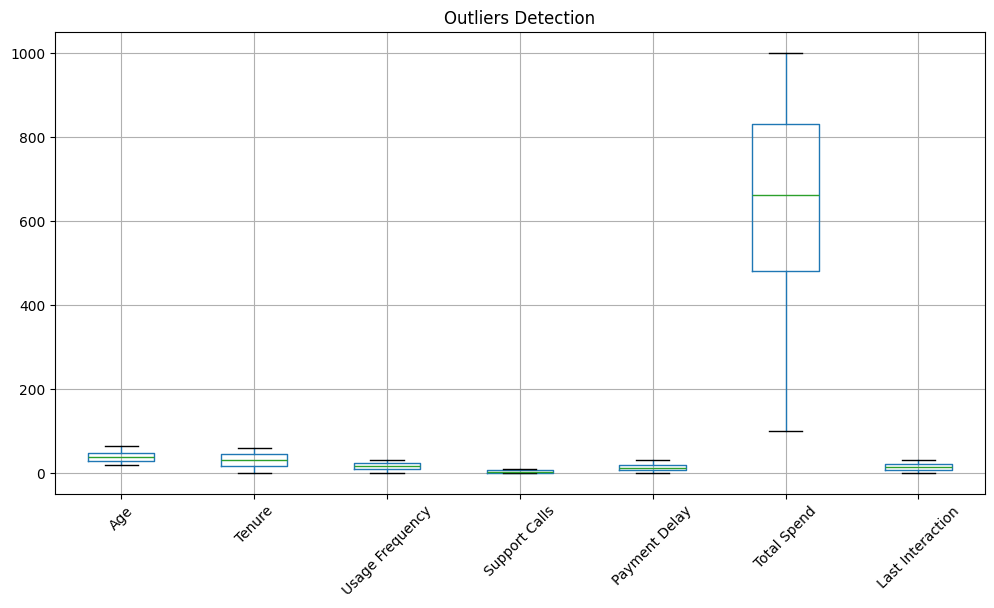

In [47]:
plt.figure(figsize=(12,6))
df[['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']].boxplot()
plt.xticks(rotation=45)
plt.title('Outliers Detection')
plt.show()

## **Rozkład wieku i wydatków - wykrywanie błędów czy nie ma danych na minusie**

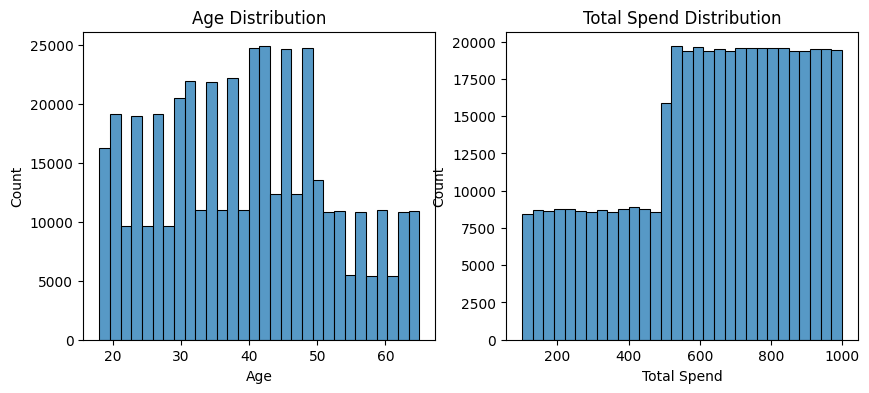

In [82]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df['Age'], bins=30)
plt.title('Age Distribution')

plt.subplot(1,2,2)
sns.histplot(df['Total Spend'], bins=30)
plt.title('Total Spend Distribution')
plt.show()

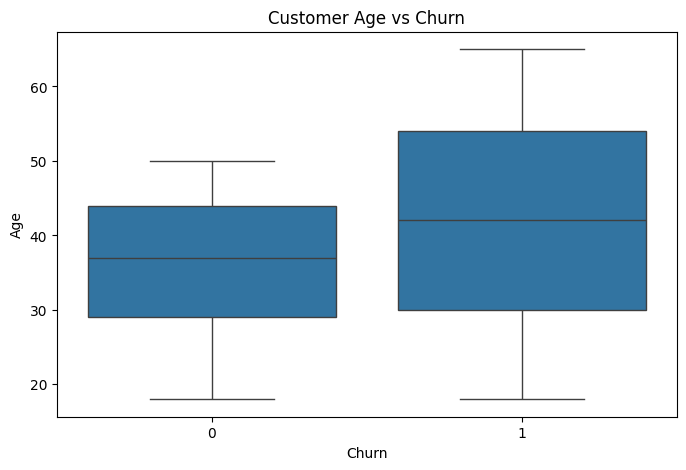

In [49]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='Age', data=df)
plt.title('Customer Age vs Churn')
plt.show()

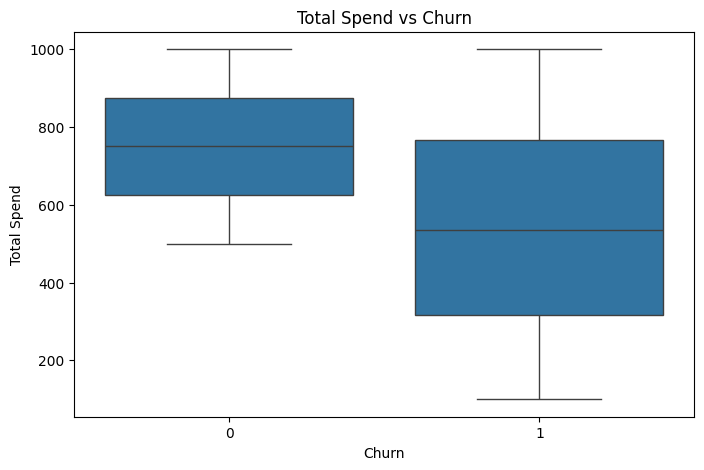

In [50]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='Total Spend', data=df)
plt.title('Total Spend vs Churn')
plt.show()

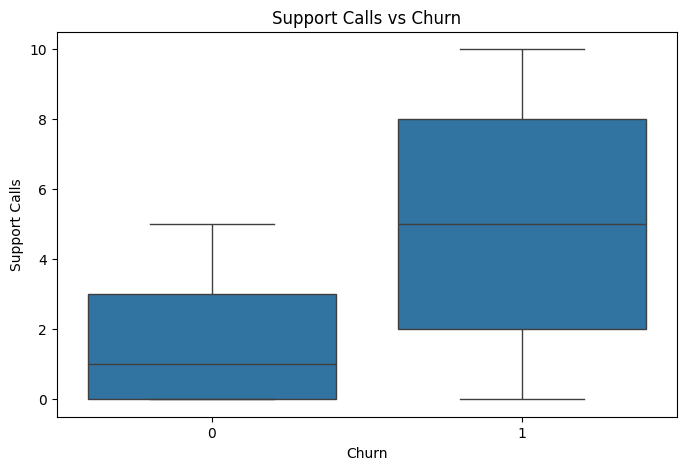

In [51]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='Support Calls', data=df)
plt.title('Support Calls vs Churn')
plt.show()

tu bylo

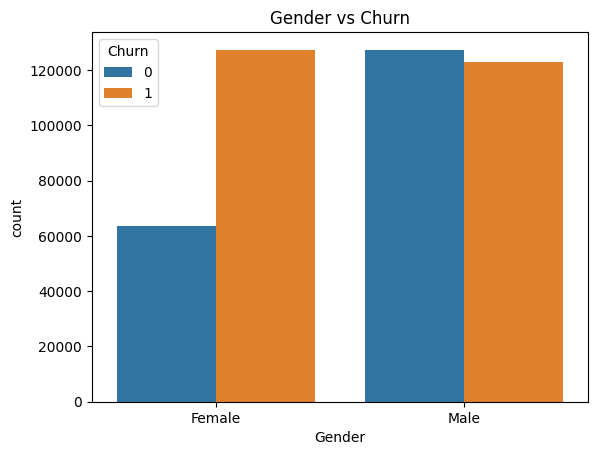

In [52]:
sns.countplot(x='Gender', hue='Churn', data=df)
plt.title('Gender vs Churn')
plt.show()

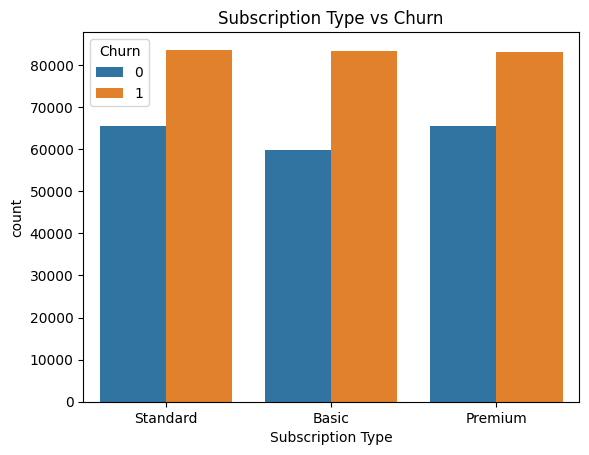

In [53]:
sns.countplot(x='Subscription Type', hue='Churn', data=df)
plt.title('Subscription Type vs Churn')
plt.show()

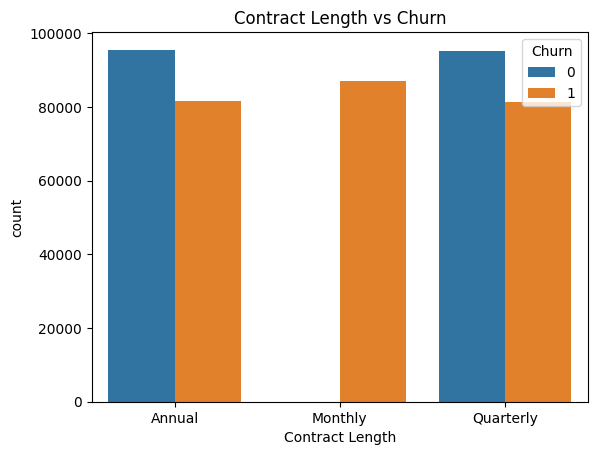

In [54]:
sns.countplot(x='Contract Length', hue='Churn', data=df)
plt.title('Contract Length vs Churn')
plt.show()

## **Kodowanie zmiennych kategorycznych**

In [55]:
df = pd.get_dummies(df, columns=['Gender', 'Subscription Type', 'Contract Length'], drop_first=True)

In [56]:
df.head()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,30.0,39.0,14.0,5.0,18.0,932.0,17.0,1,False,False,True,False,False
1,65.0,49.0,1.0,10.0,8.0,557.0,6.0,1,False,False,False,True,False
2,55.0,14.0,4.0,6.0,18.0,185.0,3.0,1,False,False,False,False,True
3,58.0,38.0,21.0,7.0,7.0,396.0,29.0,1,True,False,True,True,False
4,23.0,32.0,20.0,5.0,8.0,617.0,20.0,1,True,False,False,True,False


In [57]:
X = df.drop(columns=['Churn'])
y = df['Churn']
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

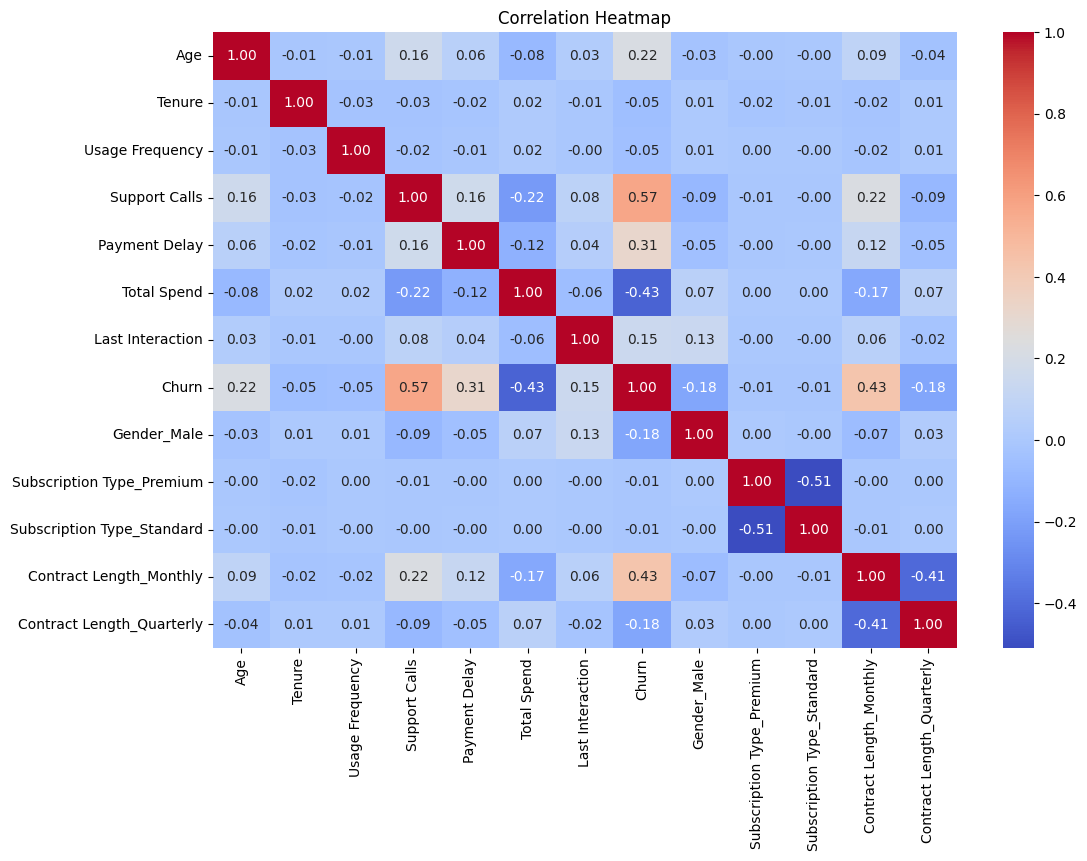

In [58]:
correlation_matrix=df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## **Przygotowanie zbioru testowego**

In [59]:
df_test = df_test.dropna()
df_test = df_test.drop(columns=['CustomerID'])
df_test = pd.get_dummies(df_test, columns=['Gender', 'Subscription Type', 'Contract Length'], drop_first=True)
df_test.head()



,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,22,25,14,4,27,598,9,1,False,False,False,True,False
1,41,28,28,7,13,584,20,0,False,False,True,True,False
2,47,27,10,2,29,757,21,0,True,True,False,False,False
3,35,9,12,5,17,232,18,0,True,True,False,False,True
4,53,58,24,9,2,533,18,0,False,False,True,False,False


## **Normalizacja**

In [60]:
num_cols = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls',
            'Payment Delay', 'Total Spend', 'Last Interaction']

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_train.head()




,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
318331,0.210377,0.855271,1.651238,-0.197156,-1.085320,1.300956,-0.753449,True,False,True,False,False
429062,-0.512784,0.681455,0.137056,-0.848223,0.246158,1.478368,-0.288211,False,False,True,False,False
60074,-1.075242,-1.056712,1.651238,0.128377,-0.116972,0.698312,-1.102379,False,True,False,False,True
12759,-0.834189,-1.288467,0.835909,2.081578,1.335549,-2.130477,0.525957,False,False,False,False,True
357321,-0.111028,-1.230528,0.486483,-1.173756,-1.569494,0.195568,0.409648,True,False,False,False,False


In [61]:
X_test = df_test.drop(columns=['Churn']).copy()
y_test = df_test['Churn']

X_test[num_cols] = scaler.transform(X_test[num_cols])

## **Regresja logistyczna**

In [62]:
results = {}
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_val)
results['Logistic Regression'] = accuracy_score(y_val, y_pred_log)

print("Regresja Logistyczna")
print(classification_report(y_val, y_pred_log, digits=4))

Regresja Logistyczna
              precision    recall  f1-score   support

           0     0.8575    0.9038    0.8801     38167
           1     0.9234    0.8854    0.9040     50000

    accuracy                         0.8934     88167
   macro avg     0.8905    0.8946    0.8920     88167
weighted avg     0.8949    0.8934    0.8936     88167



In [63]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_val)
results['Random Forest'] = accuracy_score(y_val, y_pred_rf)

print("\nRandom Forest Classifier")
print(classification_report(y_val, y_pred_rf, digits=4))


Random Forest Classifier
              precision    recall  f1-score   support

           0     0.9990    0.9999    0.9995     38167
           1     0.9999    0.9992    0.9996     50000

    accuracy                         0.9995     88167
   macro avg     0.9995    0.9996    0.9995     88167
weighted avg     0.9995    0.9995    0.9995     88167



In [64]:
xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_val)
results['XGBoost'] = accuracy_score(y_val, y_pred_xgb)

print("\nXGBoost Classifier")
print(classification_report(y_val, y_pred_xgb, digits=4))


XGBoost Classifier
              precision    recall  f1-score   support

           0     0.9998    1.0000    0.9999     38167
           1     1.0000    0.9999    0.9999     50000

    accuracy                         0.9999     88167
   macro avg     0.9999    0.9999    0.9999     88167
weighted avg     0.9999    0.9999    0.9999     88167




ZESTAWIENIE DOKŁADNOŚCI MODELI
Logistic Regression: 0.8934
Random Forest: 0.9995
XGBoost: 0.9999


<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

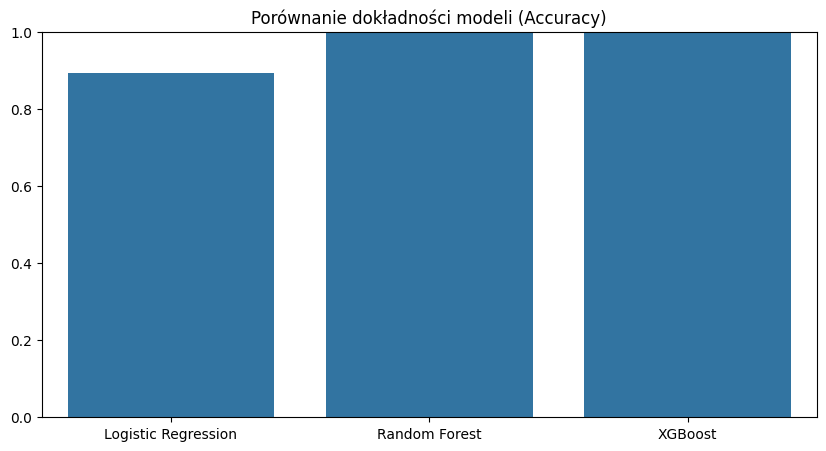

In [65]:
print("\nZESTAWIENIE DOKŁADNOŚCI MODELI")
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")
    plt.figure(figsize=(10, 5))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.title('Porównanie dokładności modeli (Accuracy)')
plt.ylim(0, 1)
plt.show()

In [66]:
df.columns.tolist()

['Age',
 'Tenure',
 'Usage Frequency',
 'Support Calls',
 'Payment Delay',
 'Total Spend',
 'Last Interaction',
 'Churn',
 'Gender_Male',
 'Subscription Type_Premium',
 'Subscription Type_Standard',
 'Contract Length_Monthly',
 'Contract Length_Quarterly']

##**Tuning hiperparametrów (Random Search CV)**

In [67]:
param_dist = {
    'n_estimators':     [100, 200, 300, 500],   # ile drzew
    'max_depth':        [3, 4, 5, 6, 7],         # jak głębokie drzewa
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],  # jak szybko się uczy
    'subsample':        [0.6, 0.8, 1.0],          # % wierszy na drzewo
    'colsample_bytree': [0.6, 0.8, 1.0],          # % kolumn na drzewo
}

random_search = RandomizedSearchCV(
    estimator=XGBClassifier(eval_metric='logloss', random_state=42),
    param_distributions=param_dist,
    n_iter=15,
    scoring='recall',   # optymalizuj pod Recall recall
    cv=3,               # każdą kombinację sprawdź 3 razy
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train, y_train)

# Najlepsze parametry
print("Najlepsze parametry:", random_search.best_params_)
print(f"Najlepszy Recall (CV): {random_search.best_score_:.4f}")

# Model z najlepszymi parametrami
xgb_tuned = random_search.best_estimator_

# Predykcja
y_pred_tuned = xgb_tuned.predict(X_val)
y_prob_tuned = xgb_tuned.predict_proba(X_val)[:, 1]

print("\nXGBoost po tuningu:")
print(classification_report(y_val, y_pred_tuned, digits=4))


Najlepsze parametry: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 1.0}
Najlepszy Recall (CV): 0.9999

XGBoost po tuningu:
              precision    recall  f1-score   support

           0     0.9998    1.0000    0.9999     38167
           1     1.0000    0.9999    0.9999     50000

    accuracy                         0.9999     88167
   macro avg     0.9999    0.9999    0.9999     88167
weighted avg     0.9999    0.9999    0.9999     88167



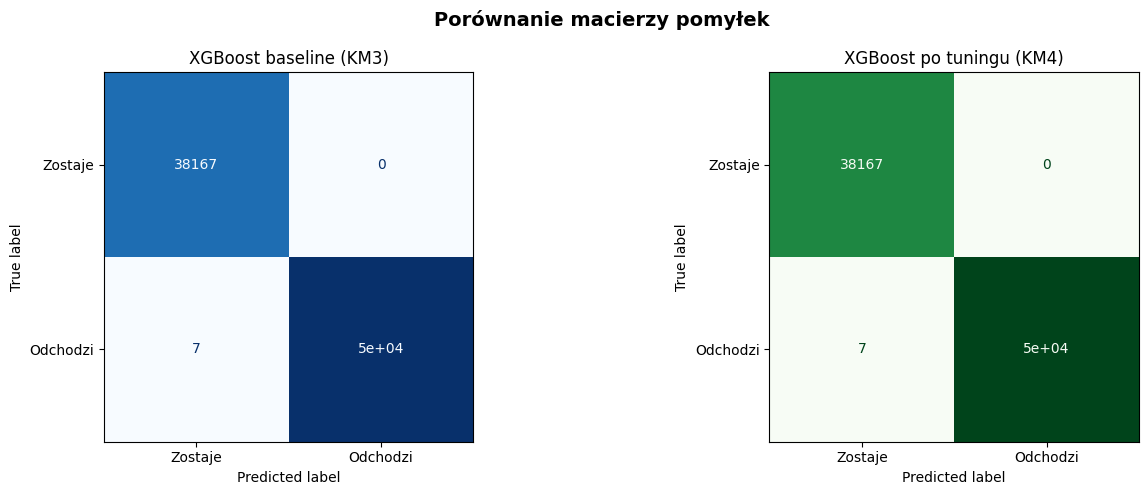

In [68]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Baseline (model z KM3)
ConfusionMatrixDisplay(
    confusion_matrix(y_val, y_pred_xgb),
    display_labels=['Zostaje', 'Odchodzi']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('XGBoost baseline (KM3)')

# Model po tuningu
ConfusionMatrixDisplay(
    confusion_matrix(y_val, y_pred_tuned),
    display_labels=['Zostaje', 'Odchodzi']
).plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('XGBoost po tuningu (KM4)')

plt.suptitle('Porównanie macierzy pomyłek', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_4283/225040096.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='viridis')


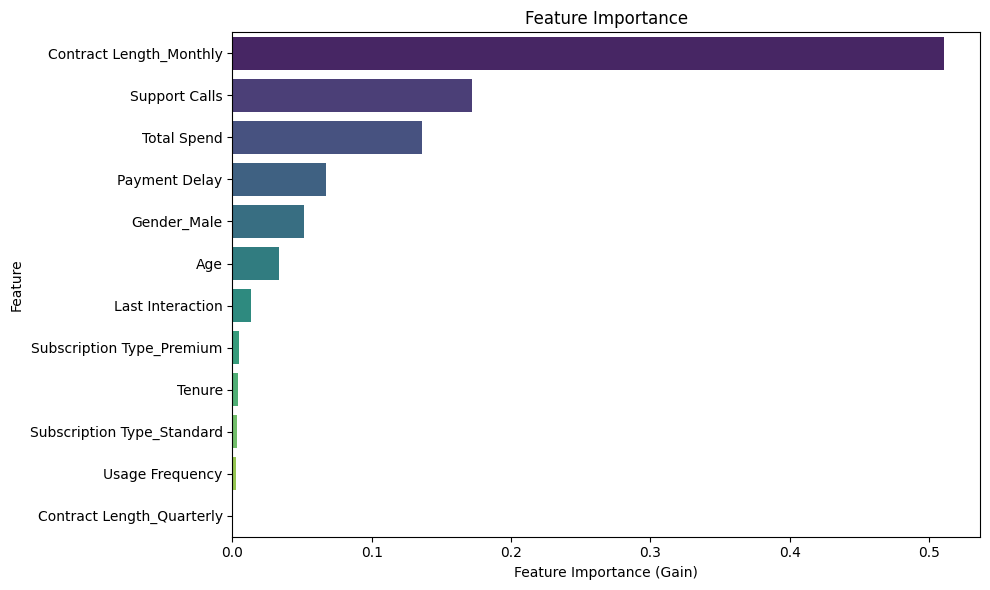


Top 5 najważniejszych cech:
Contract Length_Monthly    0.511151
Support Calls              0.172095
Total Spend                0.135969
Payment Delay              0.067443
Gender_Male                0.051187
dtype: float32


In [83]:
importances = pd.Series(
    xgb_tuned.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Feature Importance')
plt.xlabel('Feature Importance (Gain)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nTop 5 najważniejszych cech:")
print(importances.head(5))

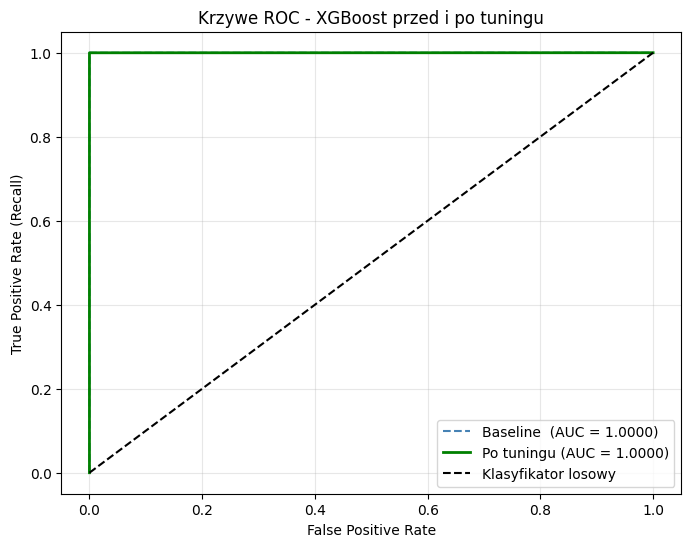

AUC Baseline:   1.0000
AUC po tuningu: 1.0000


In [70]:

# Prawdopodobieństwa dla baseline
y_prob_base = xgb_model.predict_proba(X_val)[:, 1]

fpr_base,  tpr_base,  _ = roc_curve(y_val, y_prob_base)
fpr_tuned, tpr_tuned, _ = roc_curve(y_val, y_prob_tuned)

auc_base  = auc(fpr_base,  tpr_base)
auc_tuned = auc(fpr_tuned, tpr_tuned)

plt.figure(figsize=(8, 6))
plt.plot(fpr_base,  tpr_base,  label=f'Baseline  (AUC = {auc_base:.4f})',  linestyle='--', color='steelblue')
plt.plot(fpr_tuned, tpr_tuned, label=f'Po tuningu (AUC = {auc_tuned:.4f})', linewidth=2,   color='green')
plt.plot([0, 1], [0, 1], 'k--', label='Klasyfikator losowy')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Krzywe ROC - XGBoost przed i po tuningu')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"AUC Baseline:   {auc_base:.4f}")
print(f"AUC po tuningu: {auc_tuned:.4f}")

##**Serializacja - Zapis modelu i skalera**

In [71]:
SAVE_DIR    = '/content/drive/MyDrive/Colab Notebooks/'
MODEL_PATH  = SAVE_DIR + 'xgb_tuned_model.pkl'
SCALER_PATH = SAVE_DIR + 'scaler.pkl'
PIPE_PATH   = SAVE_DIR + 'churn_pipeline.pkl'

joblib.dump(xgb_tuned, MODEL_PATH)
print(f"Model zapisany:  {MODEL_PATH}")

joblib.dump(scaler, SCALER_PATH)
print(f"Skaler zapisany: {SCALER_PATH}")

Model zapisany:  /content/drive/MyDrive/Colab Notebooks/xgb_tuned_model.pkl
Skaler zapisany: /content/drive/MyDrive/Colab Notebooks/scaler.pkl


##**Budowa pipelinu predykcji**

In [72]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

NUM_COLS = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls',
            'Payment Delay', 'Total Spend', 'Last Interaction']

# Pobieramy kolejność kolumn, na której trenowany był XGBoost
feature_order = list(X_train.columns)

# Tworzymy czysty preprocesor, który skaluje TYLKO kolumny numeryczne,
# a resztę (zmienne dummy) zostawia bez zmian w tej samej kolejności.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', scaler, NUM_COLS)
    ],
    remainder='passthrough'
)

# Przygotujmy surowe dane treningowe (przed skalowaniem) do poprawnego "uzbrojenia" pipeline'u
X_train_raw = X_train.copy()
X_train_raw[NUM_COLS] = scaler.inverse_transform(X_train[NUM_COLS])

churn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', xgb_tuned)
])

churn_pipeline.fit(X_train_raw, y_train)

joblib.dump(churn_pipeline, PIPE_PATH)
print(f"Pipeline zapisany: {PIPE_PATH}")

# Fit na SUROWYCH danych - skaler nauczy się poprawnych parametrów
churn_pipeline.steps[0][1].fit(X_train_raw)

joblib.dump(churn_pipeline, PIPE_PATH)
print(f"Pipeline zapisany: {PIPE_PATH}")

Pipeline zapisany: /content/drive/MyDrive/Colab Notebooks/churn_pipeline.pkl
Pipeline zapisany: /content/drive/MyDrive/Colab Notebooks/churn_pipeline.pkl


##**Weryfikacja - wczytanie z dysku i predykcja**

In [73]:
loaded_pipeline = joblib.load(PIPE_PATH)
print("\nPipeline wczytany z dysku – weryfikacja na zbiorze testowym:")

# Budujemy CAŁKOWICIE SUROWY zbiór testowy bezpośrednio z df_test
X_test_raw = df_test.drop(columns=['Churn'])
y_test_raw = df_test['Churn']

# Zapewniamy identyczną strukturę kolumn jak w X_train
X_test_raw = X_test_raw.reindex(columns=feature_order, fill_value=0)

# Predykcja przez pipeline
y_pred_pipe = loaded_pipeline.predict(X_test_raw)
y_prob_pipe = loaded_pipeline.predict_proba(X_test_raw)[:, 1]

# Obliczanie metryk
acc  = accuracy_score(y_test_raw,  y_pred_pipe)
prec = precision_score(y_test_raw, y_pred_pipe)
rec  = recall_score(y_test_raw,    y_pred_pipe)
f1   = f1_score(y_test_raw,        y_pred_pipe)
fpr, tpr, _ = roc_curve(y_test_raw, y_prob_pipe)
roc_auc      = auc(fpr, tpr)

print(f"\n  Accuracy  : {acc:.4f}")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  AUC-ROC   : {roc_auc:.4f}")
print("\nRaport klasyfikacji (zbiór testowy):")
print(classification_report(y_test_raw, y_pred_pipe, digits=4,
                             target_names=['Zostaje (0)', 'Odchodzi (1)']))


Pipeline wczytany z dysku – weryfikacja na zbiorze testowym:

  Accuracy  : 0.5034
  Precision : 0.4882
  Recall    : 0.9987
  F1-Score  : 0.6558
  AUC-ROC   : 0.6523

Raport klasyfikacji (zbiór testowy):
              precision    recall  f1-score   support

 Zostaje (0)     0.9804    0.0576    0.1088     33881
Odchodzi (1)     0.4882    0.9987    0.6558     30493

    accuracy                         0.5034     64374
   macro avg     0.7343    0.5282    0.3823     64374
weighted avg     0.7472    0.5034    0.3679     64374



In [74]:
joblib.dump(xgb_tuned, 'xgb_tuned_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Zapisano!")
from google.colab import files
files.download('xgb_tuned_model.pkl')
files.download('scaler.pkl')

Zapisano!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##**Wykresy - ocena na zbiorze testowym**

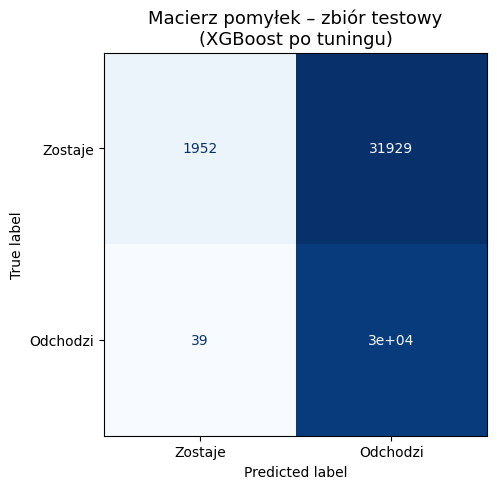

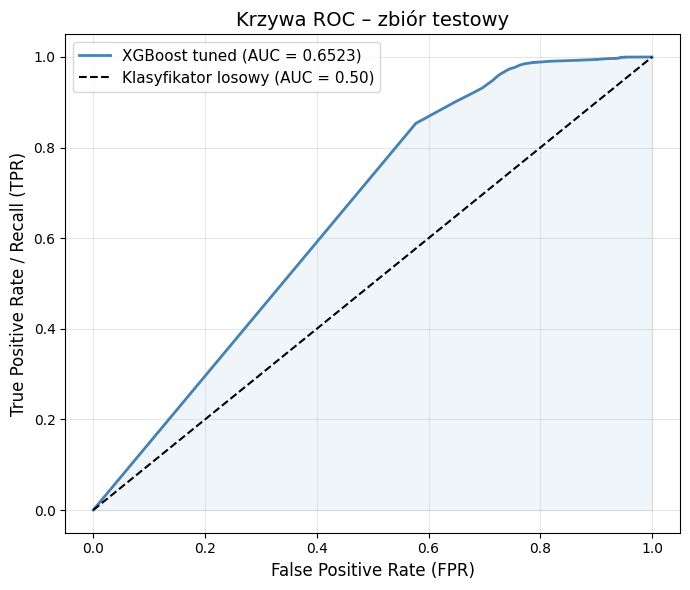

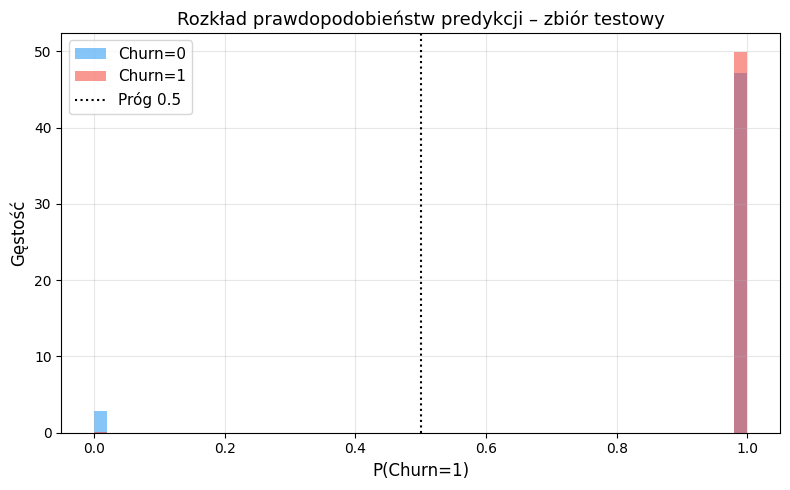

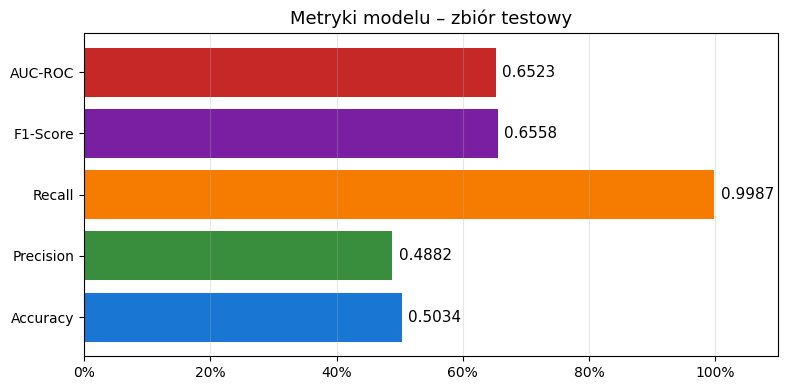

In [75]:
# Macierz pomyłek
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_pipe),
    display_labels=['Zostaje', 'Odchodzi']
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Macierz pomyłek – zbiór testowy\n(XGBoost po tuningu)', fontsize=13)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'confusion_matrix_test.png', dpi=150)
plt.show()

# Krzywa ROC
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2,
         label=f'XGBoost tuned (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Klasyfikator losowy (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.08, color='steelblue')
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate / Recall (TPR)', fontsize=12)
plt.title('Krzywa ROC – zbiór testowy', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'roc_curve_test.png', dpi=150)
plt.show()

# Rozkład prawdopodobieństw
plt.figure(figsize=(8, 5))
for label, color in [(0, '#2196F3'), (1, '#F44336')]:
    mask = (y_test == label)
    plt.hist(y_prob_pipe[mask], bins=50, alpha=0.55, color=color,
             label=f'Churn={label}', density=True)
plt.axvline(0.5, color='k', linestyle=':', linewidth=1.5, label='Próg 0.5')
plt.xlabel('P(Churn=1)', fontsize=12)
plt.ylabel('Gęstość', fontsize=12)
plt.title('Rozkład prawdopodobieństw predykcji – zbiór testowy', fontsize=13)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'prob_distribution_test.png', dpi=150)
plt.show()

# Podsumowanie metryk
metrics_df = pd.DataFrame({
    'Metryka': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC'],
    'Wartość': [acc, prec, rec, f1, roc_auc]
})
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(metrics_df['Metryka'], metrics_df['Wartość'],
               color=['#1976D2','#388E3C','#F57C00','#7B1FA2','#C62828'])
ax.set_xlim(0, 1.1)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.01, bar.get_y() + bar.get_height()/2,
            f'{w:.4f}', va='center', fontsize=11)
ax.set_title('Metryki modelu – zbiór testowy', fontsize=13)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'metrics_summary_test.png', dpi=150)
plt.show()

##**Predykcja na nowych obserwacjach**

In [76]:
# Symulacja 5 nowych klientów (dane raw, przed skalowaniem)
sample_raw = pd.DataFrame({
    'Age':                          [25,  55,  34,  47,  62],
    'Tenure':                       [1,   48,  12,  24,  60],
    'Usage Frequency':              [2,   28,  10,  20,  5 ],
    'Support Calls':                [8,   0,   3,   1,   7 ],
    'Payment Delay':                [20,  0,   5,   2,   15],
    'Total Spend':                  [150, 900, 400, 700, 200],
    'Last Interaction':             [30,  2,   14,  5,   25],
    'Gender_Male':                  [1,   0,   1,   0,   1 ],
    'Subscription Type_Premium':    [0,   1,   0,   1,   0 ],
    'Subscription Type_Standard':   [0,   0,   1,   0,   0 ],
    'Contract Length_Monthly':      [1,   0,   0,   0,   1 ],
    'Contract Length_Quarterly':    [0,   0,   1,   0,   0 ],
})
sample_raw = sample_raw.reindex(columns=X_train.columns, fill_value=0)

predictions   = loaded_pipeline.predict(sample_raw)
probabilities = loaded_pipeline.predict_proba(sample_raw)[:, 1]

result_df = sample_raw[['Age', 'Tenure', 'Support Calls', 'Total Spend']].copy()
result_df['P(Churn=1)'] = probabilities.round(4)
result_df['Predykcja']  = ['Odchodzi' if p == 1 else 'Zostaje' for p in predictions]
print("\nDemonstracja predykcji na nowych obserwacjach:")
print(result_df.to_string(index=False))


Demonstracja predykcji na nowych obserwacjach:
 Age  Tenure  Support Calls  Total Spend  P(Churn=1) Predykcja
  25       1              8          150      1.0000  Odchodzi
  55      48              0          900      0.9999  Odchodzi
  34      12              3          400      1.0000  Odchodzi
  47      24              1          700      0.0000   Zostaje
  62      60              7          200      1.0000  Odchodzi


##**Skrypt predykcji - funkcja do wielokrotnego użycia!**

In [77]:
def predict_churn(new_data: pd.DataFrame,
                  pipeline_path: str = PIPE_PATH,
                  threshold: float = 0.5) -> pd.DataFrame:
    pipe  = joblib.load(pipeline_path)
    proba = pipe.predict_proba(new_data)[:, 1]
    pred  = (proba >= threshold).astype(int)
    out   = new_data.copy()
    out['P(Churn=1)'] = proba.round(4)
    out['Predykcja']  = ['Odchodzi' if p == 1 else 'Zostaje' for p in pred]
    return out

# wyniki = predict_churn(sample_raw, threshold=0.4)
# print(wyniki)